In [1]:
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import cifar10 

In [3]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_test.shape

(10000, 32, 32, 3)

In [8]:
y_train.shape

(50000, 1)

In [9]:
import matplotlib.pyplot as plt

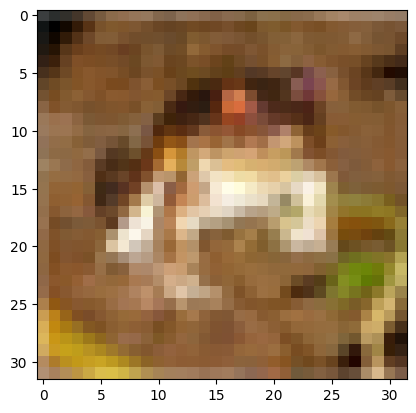

In [10]:
plt.imshow(x_train[0])

In [11]:
y_train[0]

array([6], dtype=uint8)

In [12]:
x_train=x_train/255
x_test=x_test/255

In [18]:
y_train=y_train.reshape((50000,))
y_test=y_test.reshape((10000,))

In [23]:
import numpy as np
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [24]:
from tensorflow.keras.utils import to_categorical

In [25]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense

In [27]:
model=Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history=model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=25,
    validation_split=0.2
)

Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.8145 - loss: 0.5222 - val_accuracy: 0.6945 - val_loss: 0.9845
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.8343 - loss: 0.4644 - val_accuracy: 0.6943 - val_loss: 1.0478
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8489 - loss: 0.4254 - val_accuracy: 0.7016 - val_loss: 1.0168
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8633 - loss: 0.3878 - val_accuracy: 0.7041 - val_loss: 1.0624
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.8725 - loss: 0.3585 - val_accuracy: 0.7012 - val_loss: 1.1101
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8830 - loss: 0.3285 - val_accuracy: 0.7066 - val_loss: 1.1250
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8935 - loss: 0.2992 - val_accuracy: 0.6990 - val_loss: 1.2777
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.9026 -

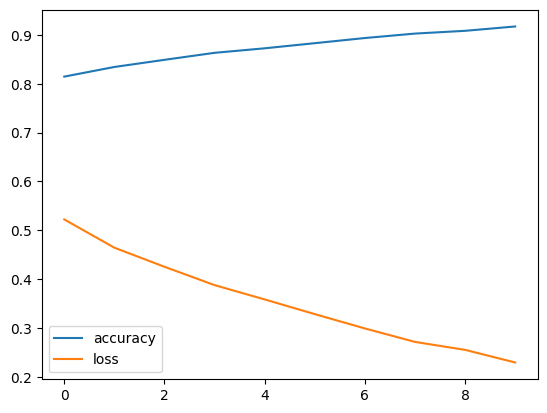

In [31]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['loss'],label='loss')
plt.legend()

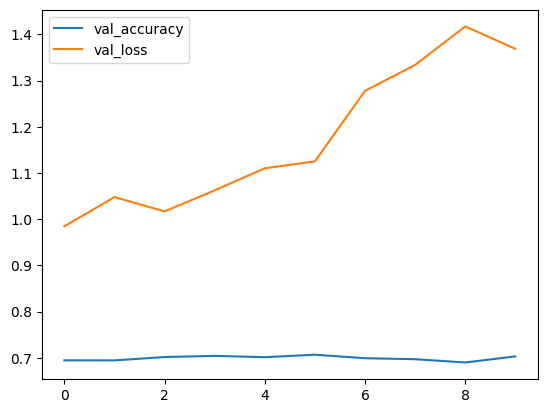

In [32]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()

In [33]:
model.save('cifar10_model.keras')

In [34]:
from tensorflow.keras import models

In [35]:
load_model=models.load_model('cifar10_model.keras')

In [36]:
loss,accuracy=load_model.evaluate(x_test,y_test)
loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7018 - loss: 1.3796


1.3796180486679077

In [37]:
accuracy

0.7017999887466431

In [38]:
x_sample=x_test[:10]
y_sample=y_test[:10]

In [39]:
y_pred=load_model.predict(x_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


In [47]:
import numpy as np
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

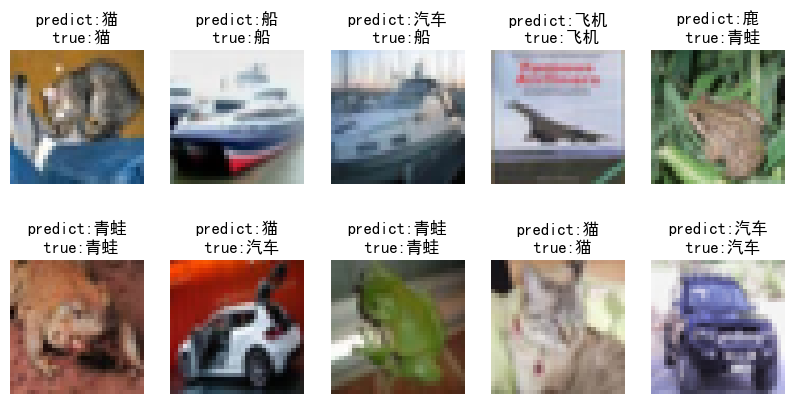

In [49]:
cifar10_classes = ['飞机', '汽车', '鸟类', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_sample[i])
    plt.axis('off')
    plt.title(f'predict:{cifar10_classes[np.argmax(y_pred[i])]}\n true:{cifar10_classes[np.argmax(y_sample[i])]}')